# Bayesian linear fit with emcee

We model the data with a straight line:

$y_{\text{model}} = mx + b$

The parameters are:

$\theta = (b, m)$

In this first Bayesian version, we assume independent Gaussian errors only on y:

$y_i \sim \mathcal{N}(mx_i + b, \sigma_{y,i}^2)$

We ignore uncertainties in x and correlations $\rho_{xy}$ for now.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize
np.random.seed(42)

In [2]:
ID = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
               11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

x = np.array([201, 244, 47, 287, 203, 58, 210, 202, 198, 158,
              165, 201, 157, 131, 166, 160, 186, 125, 218, 146])

y = np.array([592, 401, 583, 402, 495, 173, 479, 504, 510, 416,
              393, 442, 317, 311, 400, 337, 423, 334, 533, 344])

sigma_y = np.array([61, 25, 38, 15, 21, 15, 27, 14, 30, 16,
                    14, 25, 52, 16, 34, 31, 42, 26, 16, 22])

In [3]:
mask = ID >= 5

x_fit = x[mask]
y_fit = y[mask]
sigma_y_fit = sigma_y[mask]

## Prior

We use a uniform prior on the two parameters:

\[
-100 < b < 200
\]

\[
0 < m < 5
\]

This prior is broad compared to the expected best-fit values.
It mainly excludes clearly unreasonable values for this toy problem.

In [4]:
#essential functions
def compute_chi2(theta, x, y, sigma_y):
    b, m = theta
    y_model = m * x + b
    residuals = y - y_model
    return np.sum((residuals / sigma_y)**2)

def log_likelihood(theta, x, y, sigma_y):
    return -0.5 * compute_chi2(theta, x, y, sigma_y)

def log_prior(theta):
    b, m = theta

    if -100 < b < 200 and 0 < m < 5:
        return 0.0
    else:
        return -np.inf

def log_posterior(theta, x, y, sigma_y):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, x, y, sigma_y)

def neg_log_likelihood(theta, x, y, sigma_y):
    return -log_likelihood(theta, x, y, sigma_y)

def neg_log_posterior(theta, x, y, sigma_y):
    lp = log_posterior(theta, x, y, sigma_y)

    if not np.isfinite(lp):
        return 1e100

    return -lp

In [5]:
theta0 = np.array([30.0,2.0])  #initial guess

result = minimize(neg_log_posterior, theta0, args=(x_fit, y_fit, sigma_y_fit))
theta_best =result.x
print(theta_best)
print(result.fun)

[34.04775498  2.23992067]
9.340384955621545


## MCMC sampling

The optimizer gives one best-fit point, but Bayesian inference asks for a distribution of plausible parameter values.

We initialize the walkers close to the best-fit point:

$$
\theta_{\text{best}} = (b_{\text{best}}, m_{\text{best}})
$$

Then emcee samples the posterior distribution:

$$
p(b,m \mid x,y,\sigma_y)
$$

In [6]:
import emcee

ndim = 2
nwalkers = 32
pos = theta_best + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior,
    args=(x_fit, y_fit, sigma_y_fit)
)
_ = sampler.run_mcmc(pos, 5000, progress=False)

In [7]:
samples = sampler.get_chain()

print(samples.shape)

(5000, 32, 2)


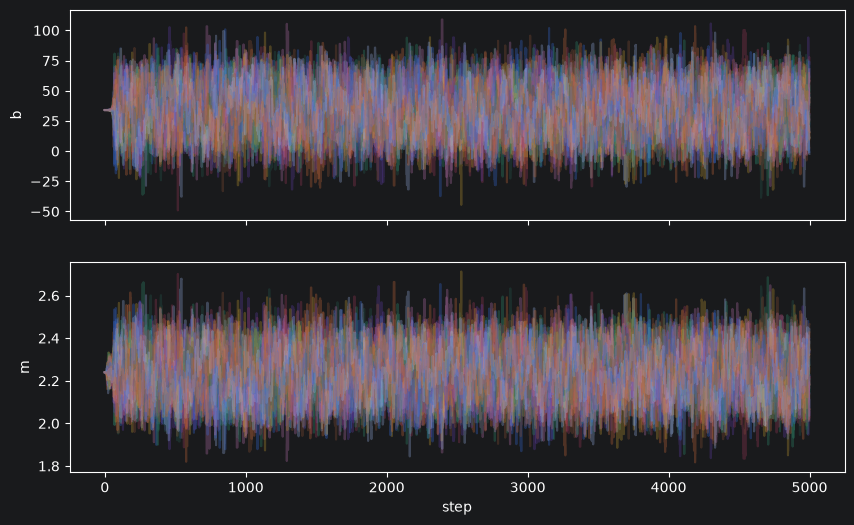

In [8]:
labels = ["b", "m"]

fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True)

for i in range(ndim):
    axes[i].plot(samples[:, :, i], alpha=0.3)
    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("step")
plt.show()

The trace plots appear stationary after a short initial phase.
The first 500 steps are discarded as burn-in. All remaining samples are kept.
Successive MCMC samples can be correlated, so the number of stored samples is
not the same as the effective number of independent samples.

In [9]:
flat_samples = sampler.get_chain(discard=500, flat=True)

print(flat_samples.shape)

(144000, 2)


In [10]:
b_samples = flat_samples[:, 0]
m_samples = flat_samples[:, 1]

b_median = np.percentile(b_samples, 50)
b_minus = b_median - np.percentile(b_samples, 16)
b_plus = np.percentile(b_samples, 84) - b_median

m_median = np.percentile(m_samples, 50)
m_minus = m_median - np.percentile(m_samples, 16)
m_plus = np.percentile(m_samples, 84) - m_median

print(f"b = {b_median:.2f} -{b_minus:.2f} +{b_plus:.2f}")
print(f"m = {m_median:.3f} -{m_minus:.3f} +{m_plus:.3f}")

b = 34.15 -18.22 +18.23
m = 2.238 -0.107 +0.108


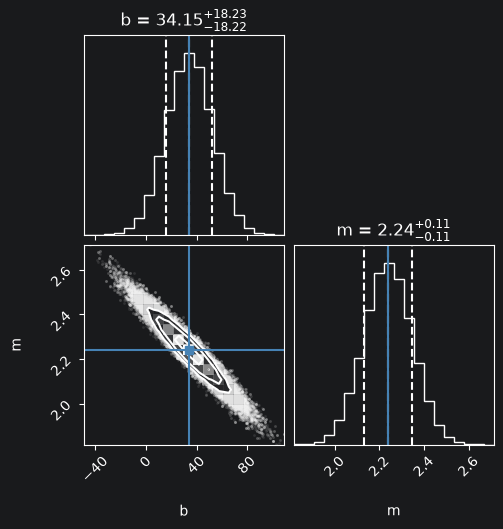

In [11]:
import corner

fig = corner.corner(
    flat_samples,
    labels=["b", "m"],
    truths=theta_best,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)
plt.show()

## Interpretation

The posterior distribution gives plausible values of the intercept b and slope m, not only one best-fit value.

The median values are close to the maximum-likelihood result, which is expected because the prior is broad and flat near the best-fit region.

The corner plot also shows the correlation between b and m: changing the slope can partly be compensated by changing the intercept.